
Gini Index values:
Online_enrolled : 0.4417
Student_BG : 0.3111
Working_status : 0.3781

Accuracy: 0.8


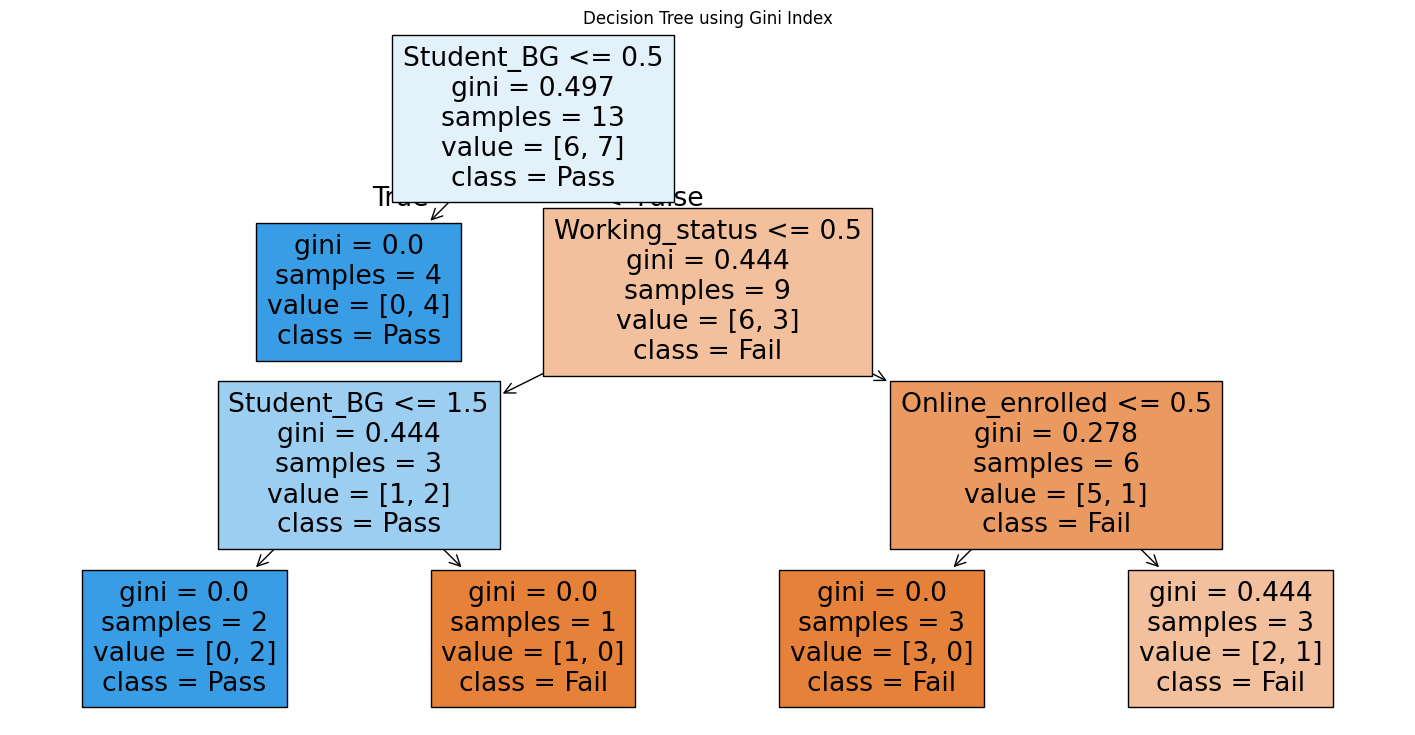

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score


data = {
    "Online_enrolled": [
        "Y","N","Y","Y","N","Y","Y","Y","N","N",
        "Y","N","Y","N","N",
        "Y","N","Y"
    ],

    "Student_BG": [
        "Maths","Maths","Maths","CS","Other","Other","Maths","CS","Maths","CS",
        "CS","Maths","Other","Other","Maths",
        "CS","Maths","Other"
    ],

    "Working_status": [
        "NW","W","W","NW","W","W","NW","NW","W","W",
        "W","NW","W","NW","W",
        "NW","W","W"
    ],

    "Result": [
        "Pass","Fail","Fail","Pass","Fail","Fail","Pass","Pass","Pass","Pass",
        "Pass","Pass","Fail","Fail","Fail",
        "Pass","Fail","Pass"
    ]
}

df = pd.DataFrame(data)


# Label Encoding
encoder = LabelEncoder()
for col in df.columns:
    df[col] = encoder.fit_transform(df[col])


# Manual Gini Index Calculation
def gini_index(data, feature, target="Result"):
    total = len(data)
    gini = 0.0

    for value in data[feature].unique():
        subset = data[data[feature] == value]
        size = len(subset)

        if size == 0:
            continue

        p_pass = len(subset[subset[target] == 1]) / size
        p_fail = len(subset[subset[target] == 0]) / size

        gini_subset = 1 - (p_pass**2 + p_fail**2)
        gini += (size / total) * gini_subset

    return gini


print("\nGini Index values:")
for feature in ["Online_enrolled", "Student_BG", "Working_status"]:
    print(feature, ":", round(gini_index(df, feature), 4))


#Train-Test Split (13–5)
X = df.drop("Result", axis=1)
y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=5, random_state=42
)


# Train Decision Tree
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)


# ACCURACY
y_pred = model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))


# Decision Tree
plt.figure(figsize=(18, 9))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True
)
plt.title("Decision Tree using Gini Index")
plt.show()
